<a href="https://colab.research.google.com/github/Shashwat-Raj/Ascendeum_Assignment_Task/blob/main/NN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. [Forward Propagation - Step by Step](#forward-propagation)
2. [Backward Propagation - The Magic Behind Learning](#backward-propagation)
3. [Complete Implementation with Code](#complete-implementation)

## 1. Forward Propagation - Step by Step {#forward-propagation}

### 🚀 The Journey of Data Through the Network

Forward propagation is like following a recipe:

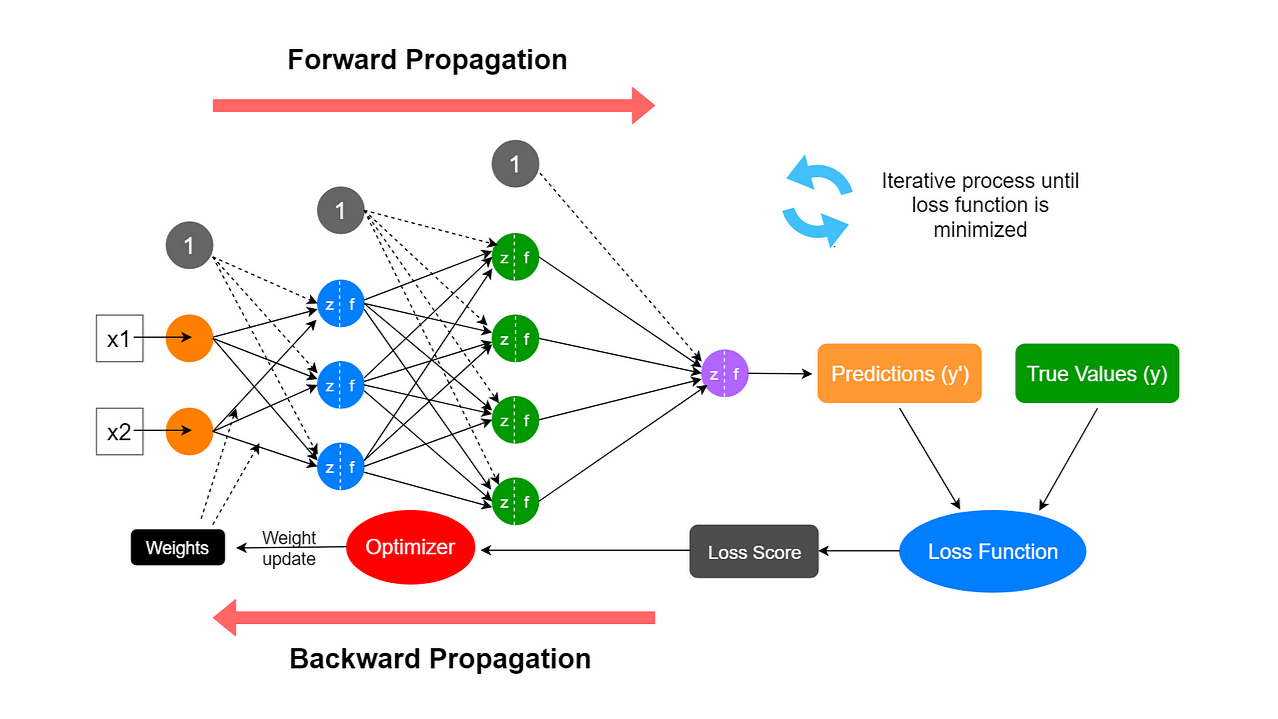

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size=2, output_size=3):
        """Initialize our baby neural network"""
        # Random small weights (like random guesses to start)
        self.W = np.random.randn(input_size, output_size) * 0.01
        # Zeros for bias (neutral starting point)
        self.b = np.zeros((1, output_size))

    def forward_propagation(self, X):
        """
        The complete forward pass - data goes in, predictions come out!

        X: Input data, shape (n_samples, n_features)
           Example: [[1.5, 2.0],   # Sample 1
                     [0.5, 1.0]]   # Sample 2
        """
        # Step 1: Linear transformation (weighted sum)
        # Like mixing ingredients with different proportions
        self.Z = np.dot(X, self.W) + self.b

        print(f"Step 1 - Linear combination Z:")
        print(f"Shape: {self.Z.shape}")
        print(f"Values: {self.Z[:2]}")  # Show first 2 samples

        # Step 2: Apply softmax (convert to probabilities)
        # Like baking - raw ingredients become something useful!
        self.A = self.softmax(self.Z)

        print(f"\nStep 2 - After softmax A:")
        print(f"Shape: {self.A.shape}")
        print(f"Values: {self.A[:2]}")
        print(f"Sum of probabilities: {np.sum(self.A[0])}")  # Should be 1.0

        return self.A

    def softmax(self, Z):
        """Convert scores to probabilities"""
        # Trick: Subtract max for numerical stability
        # (Prevents overflow with large numbers)
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
# Create a mini dataset
X = np.array([[1.0, 2.0],    # Point in 2D space
              [0.5, 1.5],
              [2.0, 1.0]])

# Create and run our network
nn = NeuralNetwork(input_size=2, output_size=3)
predictions = nn.forward_propagation(X)

# Interpret the results
for i, pred in enumerate(predictions):
    print(f"\nSample {i+1}:")
    print(f"  Class A: {pred[0]:.2%} probability")
    print(f"  Class B: {pred[1]:.2%} probability")
    print(f"  Class C: {pred[2]:.2%} probability")
    print(f"  Predicted class: {np.argmax(pred)}")

Step 1 - Linear combination Z:
Shape: (3, 3)
Values: [[ 0.00726113 -0.00224281 -0.00961081]
 [ 0.00368979 -0.00051068 -0.00890501]]

Step 2 - After softmax A:
Shape: (3, 3)
Values: [[0.33626889 0.33308814 0.33064297]
 [0.33520011 0.33379507 0.33100481]]
Sum of probabilities: 1.0

Sample 1:
  Class A: 33.63% probability
  Class B: 33.31% probability
  Class C: 33.06% probability
  Predicted class: 0

Sample 2:
  Class A: 33.52% probability
  Class B: 33.38% probability
  Class C: 33.10% probability
  Predicted class: 0

Sample 3:
  Class A: 33.68% probability
  Class B: 32.94% probability
  Class C: 33.38% probability
  Predicted class: 0


### 📊 Visualizing Forward Propagation


In [ ]:
def visualize_forward_prop(X, W, b):
    """
    Step-by-step visualization of forward propagation
    """
    print("🎯 FORWARD PROPAGATION JOURNEY")
    print("=" * 50)

    # Show input
    print("📥 INPUT DATA:")
    print(f"  Shape: {X.shape}")
    print(f"  First sample: {X[0]}")

    # Show weights
    print("\n⚖️ WEIGHTS:")
    print(f"  Shape: {W.shape}")
    print(f"  Connections from first input: {W[0]}")

    # Linear combination
    Z = np.dot(X, W) + b
    print("\n➕ LINEAR COMBINATION (Z = XW + b):")
    print(f"  First sample result: {Z[0]}")
    print(f"  (Can be negative, any value)")

    # Softmax
    exp_Z = np.exp(Z)
    A = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
    print("\n🎲 AFTER SOFTMAX:")
    print(f"  First sample probabilities: {A[0]}")
    print(f"  Sum check: {np.sum(A[0]):.4f} (should be 1.0)")

    return A

## 2. Backward Propagation - The Magic Behind Learning {#backward-propagation}

### 🎯 The Big Idea

Imagine you're learning to throw darts:
1. You throw (forward propagation)
2. You see how far off you were (calculate loss)
3. You adjust your technique (backward propagation)
4. Try again with the adjustment (update weights)

### 🔄 The Chain Rule - Breaking Down Complex Problems
```python
"""
The Chain Rule in Plain English:

If you want to know: "How does changing weights affect the loss?"
Break it down:
1. How does changing weights affect Z? (Easy: dZ/dW = X)
2. How does changing Z affect probabilities? (Softmax derivative)
3. How does changing probabilities affect loss? (Cross-entropy derivative)

Then multiply them together!
dL/dW = dL/dA * dA/dZ * dZ/dW
"""

## 🎯 **Simple Explanation: How Neural Networks Learn (Backpropagation)**

Think of training a neural network like **teaching a child to recognize animals**:

---

### 📚 **The Learning Process - Like Learning to Throw Darts**

Imagine you're learning to throw darts:
1. **You throw** (Forward pass)
2. **You see where it landed** (Calculate error)
3. **You figure out what went wrong** (Backpropagation)
4. **You adjust your technique** (Update weights)

---

### 🧠 **What Each Part Does**

#### **1️⃣ Forward Pass** (Making a Guess)
```python
self.Z = np.dot(X, self.W) + self.b  # Calculate scores
self.A = self.softmax(self.Z)        # Convert to probabilities
```
- Network looks at image and guesses: "70% cat, 20% dog, 10% bird"
- Just like a student taking a multiple-choice test

#### **2️⃣ Calculate Loss** (How Wrong Were We?)
```python
correct_probs = self.A[range(m), y_true]
loss = -np.mean(np.log(correct_probs))
```
- Teacher says: "It was actually a DOG!"
- We only gave 20% to dog = **Big mistake!**
- Loss measures how wrong we were

#### **3️⃣ Backward Pass** (Figure Out What Went Wrong)
```python
self.dZ = self.A.copy()
self.dZ[range(m), y_true] -= 1  # The magic formula!
```

**The Magic Formula Explained:**
- Take your predictions: [0.7, 0.2, 0.1]
- Subtract 1 from the CORRECT answer
- If correct was class 1 (dog): [0.7, -0.8, 0.1]

**What do these numbers mean?**
- **Positive (+0.7)** = "You gave too much to CAT, reduce it!"
- **Negative (-0.8)** = "You gave too little to DOG, increase it!"
- **Small (+0.1)** = "You gave a bit too much to BIRD"

#### **4️⃣ Update Weights** (Fix Our Mistakes)
```python
self.W = self.W - learning_rate * self.dW
```
- Adjust the "importance knobs" (weights)
- Like adjusting your throwing angle after missing the dartboard

---

### 🎨 **Real Example with Numbers**

**Scenario:** Network sees a picture of a DOG

**What happens:**
1. **Network guesses:**
   - Cat: 70% ❌ (wrong!)
   - Dog: 20% ✅ (correct but too low)
   - Bird: 10% ❌

2. **Calculate error signal (dZ):**
   - Cat: +0.7 → "Reduce cat score by a lot!"
   - Dog: -0.8 → "Increase dog score by a lot!"
   - Bird: +0.1 → "Reduce bird score a little"

3. **Update weights:**
   - Weights that led to "cat" get reduced
   - Weights that lead to "dog" get increased
   - Network learns: "Next time I see these features, think DOG not CAT!"

---

### 💡 **The Simple Intuition**

**Backpropagation is like a teacher correcting homework:**

1. **Student writes:** C-A-T
2. **Teacher marks:** ❌ It's D-O-G
3. **Student learns:**
   - "Don't write C when I see four legs and barking"
   - "Do write D when I see these features"

The network adjusts its "rules" (weights) based on mistakes!

---

### 🔄 **Why It Works**

**Every training example:**
- Shows network its mistakes
- Network adjusts slightly
- After thousands of examples, it gets really good!

**It's exactly like:**
- Learning to ride a bike (fall left → lean right)
- Learning to cook (too salty → use less salt)
- Learning to write (messy → practice more)

---

### 📊 **The Gradient (Direction to Improve)**

```
Gradient = Prediction - Truth
```

**If you predicted 70% cat but it was 0% cat:**
- Gradient = 0.7 - 0 = +0.7
- Positive = "Go down!" (reduce cat probability)

**If you predicted 20% dog but it was 100% dog:**
- Gradient = 0.2 - 1.0 = -0.8  
- Negative = "Go up!" (increase dog probability)

---

### 🎯 **In One Sentence**

**Backpropagation = The network looking at its mistakes and adjusting its "guessing rules" to be less wrong next time!**

Just like you learning from experience:
- Touch hot stove → Learn "don't touch red coils"
- Eat sour lemon → Learn "yellow citrus = sour"
- See this pattern → Learn "four legs + barks = dog"

The network does the same thing, just with numbers! 🚀

## 🎯 **Let's Connect the Math to the Code - Simple Explanation**

You're right! You know the theory. Let me show you **EXACTLY** how the code connects to what you already know.

---

### 📚 **What You Already Know (The Theory)**

1. We need: **∂Loss/∂W** (how loss changes with weights)
2. Then update: **W_new = W_old - lr × (∂Loss/∂W)**

**But the problem is:** Loss doesn't directly connect to W. It goes through steps:
```
W → Z → A (softmax) → Loss
```

So we use **chain rule** to work backwards!

---

## 🔗 **The Chain Rule Path**

To get **∂Loss/∂W**, we need:
```
∂Loss/∂W = ∂Loss/∂Z × ∂Z/∂W
```

Let's find each part:

---

## 📊 **Part 1: Why We Subtract 1 (Finding ∂Loss/∂Z)**

### **The Math Behind It**

For cross-entropy loss with softmax, the derivative is surprisingly simple:

```
∂Loss/∂Z = A - Y_true
```

Where:
- **A** = our predictions (probabilities)
- **Y_true** = one-hot encoded truth

### **Example with Numbers:**

**Sample 1 (actual = Cat):**
- Predictions A = [0.24, 0.32, 0.44]
- Truth one-hot = [1, 0, 0] (it's a cat)
- **∂Loss/∂Z = [0.24-1, 0.32-0, 0.44-0] = [-0.76, 0.32, 0.44]**

**This is exactly what the code does!**
```python
self.dZ = self.A.copy()           # Start with predictions
self.dZ[range(m), y_true] -= 1    # Subtract 1 from true class position
```

### **Why This Makes Sense:**
- **-0.76 for Cat**: Negative = "Increase this!" (we only gave 24% but it should be 100%)
- **+0.32 for Dog**: Positive = "Decrease this!" (we gave 32% but it should be 0%)
- **+0.44 for Bird**: Positive = "Decrease this!" (we gave 44% but it should be 0%)

---

## 🧮 **Part 2: Finding ∂Z/∂W**

Remember: **Z = X × W + b**

So: **∂Z/∂W = X** (the derivative of XW with respect to W is just X!)

---

## 🔄 **Part 3: Combining Everything (Finding dW)**

Using chain rule:
```
∂Loss/∂W = ∂Loss/∂Z × ∂Z/∂W
         = dZ × X
         = X^T × dZ  (we transpose for matrix multiplication)
```

**This is exactly:**
```python
self.dW = np.dot(X.T, self.dZ)
```

---

## 📝 **Simple Step-by-Step Example**

Let's trace one weight update:

### **Starting Point:**
- Image features: X = [1, 2]
- Current weight: W[0,0] = 0.1 (connects input 1 to Cat output)
- Network predicted: 24% Cat
- Truth: 100% Cat (it IS a cat!)

### **Step 1: Calculate Error Signal**
```
dZ for Cat = 0.24 - 1.0 = -0.76
```
"You were 76% too low on Cat!"

### **Step 2: Calculate Weight Gradient**
```
dW[0,0] = X[0] × dZ[Cat]
        = 1 × (-0.76)
        = -0.76
```
"This weight contributed -0.76 to the error"

### **Step 3: Update Weight**
```
W[0,0]_new = W[0,0]_old - lr × dW[0,0]
           = 0.1 - 0.1 × (-0.76)
           = 0.1 + 0.076
           = 0.176
```
"Increase this weight to make Cat score higher next time!"

---

## 💡 **The Complete Picture in Simple Terms**

```python
# What we're really doing:

# 1. FORWARD: Make a guess
prediction = [0.24, 0.32, 0.44]  # "I think: 24% cat, 32% dog, 44% bird"

# 2. ERROR: How wrong were we?
truth = [1, 0, 0]  # "It's 100% cat!"
error = prediction - truth  # [-0.76, 0.32, 0.44]
# Means: "Add 76% to cat, remove 32% from dog, remove 44% from bird"

# 3. BLAME: Which weights caused this error?
# If input was [1, 2] and error was [-0.76, 0.32, 0.44]
# Then weight from input1→cat contributed: 1 × (-0.76) = -0.76

# 4. FIX: Adjust weights opposite to gradient
# If gradient is negative (-0.76), we ADD to weight
# If gradient is positive (+0.44), we SUBTRACT from weight
```

---

## 🎯 **Why This Specific Formula Works**

The magical formula `dZ = predictions - truth` comes from calculus, but here's the intuition:

**If you predicted 30% but truth is 100%:**
- Error = 30% - 100% = -70%
- Negative means "go UP"
- Update will increase this weight

**If you predicted 80% but truth is 0%:**
- Error = 80% - 0% = +80%
- Positive means "go DOWN"
- Update will decrease this weight

---

## 📊 **Visual Summary**

```
FORWARD PASS:
X --W--> Z --softmax--> A --loss--> L

BACKWARD PASS (derivatives):
L --∂L/∂A--> A --∂A/∂Z--> Z --∂Z/∂W--> W

ACTUAL CALCULATION:
1. dZ = A - Y_true        (error at output)
2. dW = X^T × dZ          (error for each weight)
3. W_new = W - lr × dW    (fix the weights)
```

---

## 🚀 **In One Sentence**

**We subtract 1 from the true class because that's the derivative of cross-entropy loss with softmax - it tells us "how wrong we were" for each class, which we then use to figure out "which weights to blame" and "how to fix them"!**

It's like:
- **Teacher marks your test**: "You got 24/100 on question 1" (dZ)
- **You figure out why**: "I didn't study chapter 3" (dW)
- **You fix it**: "Study chapter 3 more" (update W)

Does this make the connection clearer? The code is just implementing the calculus chain rule in a clever, simplified way! 🎓

In [ ]:
class NeuralNetworkWithBackprop:
    def __init__(self, input_size=2, output_size=3, learning_rate=0.1):
        self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros((1, output_size))
        self.learning_rate = learning_rate

    def forward(self, X):
        """Same as before - calculate predictions"""
        self.Z = np.dot(X, self.W) + self.b
        self.A = self.softmax(self.Z)
        return self.A

    def calculate_loss(self, y_true):
        """Calculate how wrong we were"""
        m = len(y_true)
        # Pick the probability of the correct class for each sample
        correct_probs = self.A[range(m), y_true]
        # Take negative log (cross-entropy)
        loss = -np.mean(np.log(correct_probs + 1e-7))  # Add tiny value to avoid log(0)
        return loss

    def backward(self, X, y_true):
        """
        The magic happens here! Calculate gradients.

        The math looks scary but the intuition is simple:
        - For the correct class: push probability UP (toward 1)
        - For wrong classes: push probability DOWN (toward 0)
        """
        m = len(y_true)

        # Step 1: Calculate dZ (gradient of loss w.r.t. Z)
        # This has a beautiful closed form: probabilities - one_hot(truth)
        self.dZ = self.A.copy()
        self.dZ[range(m), y_true] -= 1  # Subtract 1 from true class
        self.dZ = self.dZ / m  # Average over batch

        print("🔄 BACKWARD PROPAGATION:")
        print(f"  dZ (error signal) first sample: {self.dZ[0]}")
        print(f"  Interpretation:")
        print(f"    Positive → reduce this probability")
        print(f"    Negative → increase this probability")

        # Step 2: Calculate dW (gradient of loss w.r.t. weights)
        # How much each weight contributed to the error
        self.dW = np.dot(X.T, self.dZ)

        print(f"\n  dW shape: {self.dW.shape}")
        print(f"  Weight gradient for first input→first output: {self.dW[0,0]:.4f}")

        # Step 3: Calculate db (gradient of loss w.r.t. bias)
        self.db = np.sum(self.dZ, axis=0, keepdims=True)

        print(f"\n  db (bias gradients): {self.db[0]}")

    def update_parameters(self):
        """
        Adjust weights and biases based on gradients.
        Like adjusting your dart throw based on where you missed.
        """
        print("\n📊 PARAMETER UPDATE:")
        print(f"  Old weight[0,0]: {self.W[0,0]:.4f}")

        # Gradient descent: take a small step opposite to gradient
        self.W = self.W - self.learning_rate * self.dW
        self.b = self.b - self.learning_rate * self.db

        print(f"  New weight[0,0]: {self.W[0,0]:.4f}")
        print(f"  Change: {-self.learning_rate * self.dW[0,0]:.4f}")

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
def understand_gradient():
    """
    Let's see WHY dZ = predictions - truth makes sense
    """
    # Example: 3 classes
    predictions = np.array([0.7, 0.2, 0.1])  # Network thinks it's class 0
    true_class = 0  # It's actually class 0 (good guess!)

    # Calculate gradient
    gradient = predictions.copy()
    gradient[true_class] -= 1
    # Result: [-0.3, 0.2, 0.1]

    print("When CORRECT (predicted class 0, actual class 0):")
    print(f"  Gradients: {gradient}")
    print("  Interpretation:")
    print("    Class 0: -0.3 → increase this probability (it's correct!)")
    print("    Class 1: +0.2 → decrease this probability")
    print("    Class 2: +0.1 → decrease this probability")

    # Now if we were wrong:
    predictions = np.array([0.7, 0.2, 0.1])  # Network thinks it's class 0
    true_class = 1  # But it's actually class 1!

    gradient = predictions.copy()
    gradient[true_class] -= 1
    # Result: [0.7, -0.8, 0.1]

    print("\nWhen WRONG (predicted class 0, actual class 1):")
    print(f"  Gradients: {gradient}")
    print("  Interpretation:")
    print("    Class 0: +0.7 → strongly decrease (very wrong!)")
    print("    Class 1: -0.8 → strongly increase (this is correct!)")
    print("    Class 2: +0.1 → slightly decrease")

understand_gradient()

When CORRECT (predicted class 0, actual class 0):
  Gradients: [-0.3  0.2  0.1]
  Interpretation:
    Class 0: -0.3 → increase this probability (it's correct!)
    Class 1: +0.2 → decrease this probability
    Class 2: +0.1 → decrease this probability

When WRONG (predicted class 0, actual class 1):
  Gradients: [ 0.7 -0.8  0.1]
  Interpretation:
    Class 0: +0.7 → strongly decrease (very wrong!)
    Class 1: -0.8 → strongly increase (this is correct!)
    Class 2: +0.1 → slightly decrease


# All Together Code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleNeuralNetwork:
    """
    A simple neural network for multi-class classification.
    This is a complete, working implementation with extensive comments!
    """

    def __init__(self, n_features, n_classes, learning_rate=0.1):
        """
        Initialize the network.

        Args:
            n_features: Number of input features (e.g., 2 for x,y coordinates)
            n_classes: Number of output classes (e.g., 3 for A,B,C)
            learning_rate: How big our learning steps are (0.1 is usually good)
        """
        # Initialize weights with small random values
        # Why small? Large values can cause saturation in sigmoid/softmax
        self.W = np.random.randn(n_features, n_classes) * 0.01

        # Initialize biases to zero
        # Starting neutral - no initial preference for any class
        self.b = np.zeros((1, n_classes))

        # Learning rate - how much we adjust weights each step
        self.lr = learning_rate

        # Store dimensions for later use
        self.n_features = n_features
        self.n_classes = n_classes

        # History for plotting
        self.loss_history = []

        print(f"🧠 Neural Network initialized!")
        print(f"   Input features: {n_features}")
        print(f"   Output classes: {n_classes}")
        print(f"   Total parameters: {n_features * n_classes + n_classes}")

    def softmax(self, Z):
        """
        Convert raw scores to probabilities.

        Args:
            Z: Raw scores from linear combination, shape (n_samples, n_classes)

        Returns:
            Probabilities that sum to 1 for each sample
        """
        # Subtract max for numerical stability (prevent overflow)
        # This doesn't change the result, just makes computation safer
        Z_stable = Z - np.max(Z, axis=1, keepdims=True)

        # Exponentiate and normalize
        exp_Z = np.exp(Z_stable)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        """
        Pass data through the network to get predictions.

        Args:
            X: Input data, shape (n_samples, n_features)

        Returns:
            Predicted probabilities for each class
        """
        # Linear combination: Z = XW + b
        # This is like weighted voting - each feature votes for each class
        self.Z = np.dot(X, self.W) + self.b

        # Apply softmax to get probabilities
        # Converts any real numbers to probabilities between 0 and 1
        self.A = self.softmax(self.Z)

        return self.A

    def compute_loss(self, y_true):
        """
        Calculate how wrong our predictions are.

        Args:
            y_true: True class labels (integers like 0, 1, 2)

        Returns:
            Cross-entropy loss (lower is better)
        """
        m = len(y_true)

        # Get the predicted probability for the correct class of each sample
        # If sample i belongs to class j, we want A[i,j] to be close to 1
        correct_class_probs = self.A[range(m), y_true]

        # Cross-entropy: -log(probability of correct class)
        # If prob = 1 (perfect), loss = 0
        # If prob = 0.1 (bad), loss = 2.3
        # Add small epsilon to avoid log(0)
        loss = -np.mean(np.log(correct_class_probs + 1e-7))

        return loss

    def backward_propagation(self, X, y_true):
        """
        Calculate gradients - how to adjust weights to reduce error.

        This is where the magic happens!
        We figure out which weights caused the error and by how much.

        Args:
            X: Input data
            y_true: True labels
        """
        m = len(y_true)

        # Step 1: Calculate error at output layer
        # For softmax + cross-entropy, this has a beautiful simple form:
        # gradient = predictions - truth
        self.dZ = self.A.copy()
        self.dZ[range(m), y_true] -= 1
        self.dZ = self.dZ / m  # Average over all samples

        # Step 2: Calculate weight gradients
        # How much did each weight contribute to the error?
        # dW = X^T @ dZ (input × error gives weight gradient)
        self.dW = np.dot(X.T, self.dZ)

        # Step 3: Calculate bias gradients
        # Bias gradient is just the sum of errors
        self.db = np.sum(self.dZ, axis=0, keepdims=True)

    def update_parameters(self):
        """
        Adjust weights and biases based on gradients.
        This is gradient descent - taking a step downhill toward lower loss.
        """
        # Take a step in the opposite direction of gradient
        # (Gradient points uphill, we want to go downhill)
        self.W = self.W - self.lr * self.dW
        self.b = self.b - self.lr * self.db

    def train_step(self, X, y):
        """
        One complete training step.

        Args:
            X: Training data
            y: Training labels

        Returns:
            Loss for this step
        """
        # 1. Forward pass - make predictions
        self.forward_propagation(X)

        # 2. Calculate loss - how wrong were we?
        loss = self.compute_loss(y)

        # 3. Backward pass - calculate gradients
        self.backward_propagation(X, y)

        # 4. Update - adjust weights
        self.update_parameters()

        return loss

    def fit(self, X, y, epochs=1000, verbose=True):
        """
        Train the network on data.

        Args:
            X: Training data
            y: Training labels
            epochs: Number of training iterations
            verbose: Whether to print progress
        """
        print(f"\n🚀 Starting training for {epochs} epochs...")

        for epoch in range(epochs):
            # One training step
            loss = self.train_step(X, y)
            self.loss_history.append(loss)

            # Print progress
            if verbose and epoch % 100 == 0:
                accuracy = self.accuracy(X, y)
                print(f"  Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.2%}")

        print(f"✅ Training complete!")

    def predict(self, X):
        """
        Make predictions on new data.

        Args:
            X: Input data

        Returns:
            Predicted class labels
        """
        # Get probabilities
        probabilities = self.forward_propagation(X)

        # Return class with highest probability
        return np.argmax(probabilities, axis=1)

    def accuracy(self, X, y):
        """Calculate prediction accuracy."""
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def plot_loss(self):
        """Visualize training progress."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss_history)
        plt.title('Training Loss Over Time')
        plt.xlabel('Epoch')
        plt.ylabel('Cross-Entropy Loss')
        plt.grid(True, alpha=0.3)
        plt.show()

🧠 Neural Network initialized!
   Input features: 2
   Output classes: 3
   Total parameters: 9

🚀 Starting training for 500 epochs...
  Epoch    0 | Loss: 1.0990 | Accuracy: 50.00%
  Epoch  100 | Loss: 0.7891 | Accuracy: 49.67%
  Epoch  200 | Loss: 0.7882 | Accuracy: 49.33%
  Epoch  300 | Loss: 0.7882 | Accuracy: 49.33%
  Epoch  400 | Loss: 0.7882 | Accuracy: 49.33%
✅ Training complete!


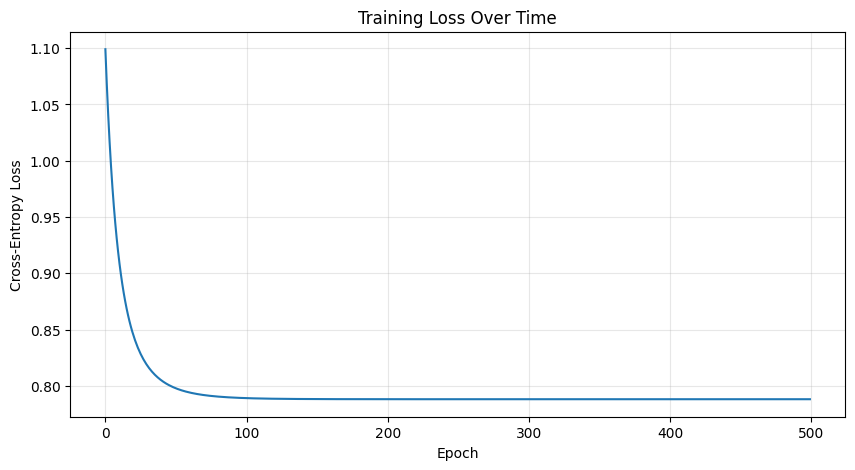


🎯 Final Training Accuracy: 49.33%


In [ ]:
# Create the famous spiral dataset
def create_spiral_dataset(n_points=100, n_classes=3):
    """
    Create a spiral dataset for testing our neural network.
    This is a challenging dataset that requires non-linear boundaries.
    """
    X = []
    y = []

    for class_idx in range(n_classes):
        # Create points along a spiral
        theta = np.linspace(class_idx * 4, (class_idx + 1) * 4, n_points)
        radius = np.linspace(0.1, 1, n_points)

        # Add some noise for realism
        theta += np.random.randn(n_points) * 0.2

        # Convert to x,y coordinates
        x1 = radius * np.sin(theta)
        x2 = radius * np.cos(theta)

        X.extend(np.column_stack([x1, x2]))
        y.extend([class_idx] * n_points)

    return np.array(X), np.array(y)

# Generate dataset
X_train, y_train = create_spiral_dataset(n_points=100, n_classes=3)

# Create and train network
nn = SimpleNeuralNetwork(n_features=2, n_classes=3, learning_rate=1.0)
nn.fit(X_train, y_train, epochs=500, verbose=True)

# Visualize results
nn.plot_loss()

# Check final accuracy
final_accuracy = nn.accuracy(X_train, y_train)
print(f"\n🎯 Final Training Accuracy: {final_accuracy:.2%}")

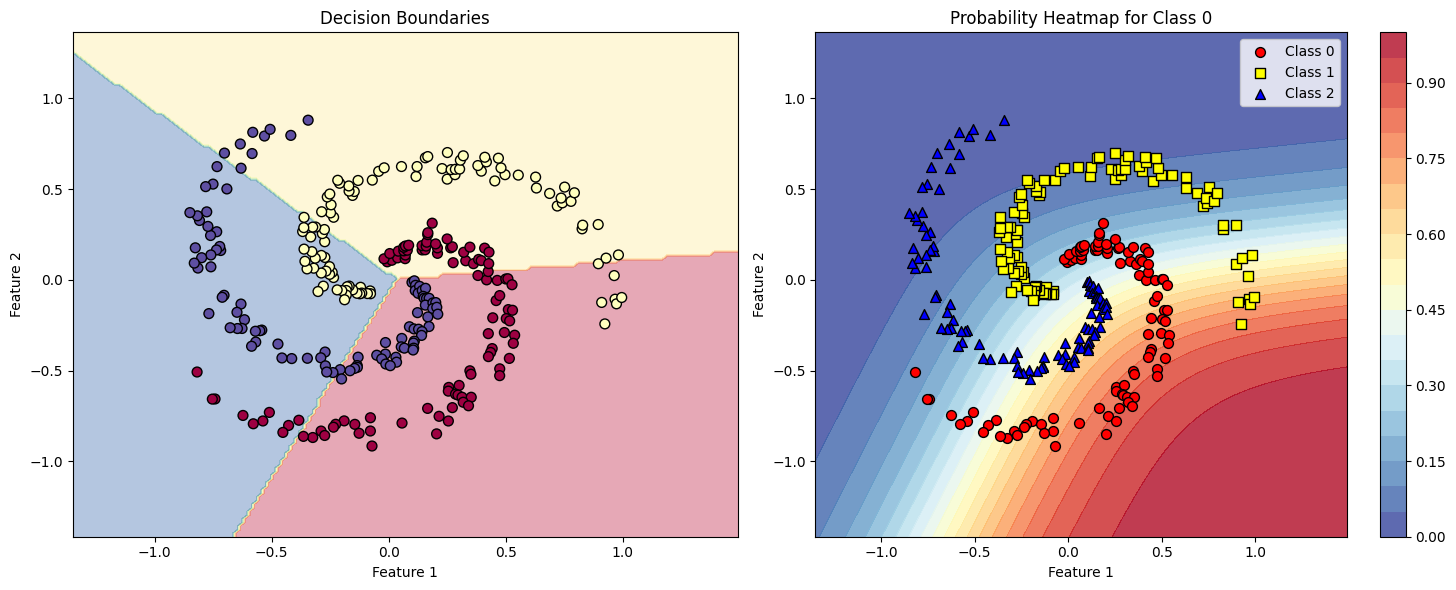

In [ ]:
def plot_decision_boundary(nn, X, y):
    """
    Visualize what our network learned!
    Shows the decision regions for each class.
    """
    # Set up the plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Create a mesh grid
    h = 0.02  # Step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for every point in the mesh
    Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot 1: Decision regions
    axes[0].contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.4)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral,
                    edgecolors='black', s=50)
    axes[0].set_title('Decision Boundaries')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')

    # Plot 2: Probability heatmap for class 0
    probabilities = nn.forward_propagation(np.c_[xx.ravel(), yy.ravel()])
    Z_prob = probabilities[:, 0].reshape(xx.shape)

    im = axes[1].contourf(xx, yy, Z_prob, levels=20, cmap='RdYlBu_r', alpha=0.8)
    axes[1].scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o',
                    edgecolors='black', s=50, label='Class 0')
    axes[1].scatter(X[y==1, 0], X[y==1, 1], c='yellow', marker='s',
                    edgecolors='black', s=50, label='Class 1')
    axes[1].scatter(X[y==2, 0], X[y==2, 1], c='blue', marker='^',
                    edgecolors='black', s=50, label='Class 2')
    axes[1].set_title('Probability Heatmap for Class 0')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].legend()

    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

# Visualize what our network learned
plot_decision_boundary(nn, X_train, y_train)

## 🎨 **Understanding These Neural Network Visualizations**


### 📊 **Plot 1: Decision Boundaries (Left)**

This shows **"Who wins where?"** - which class the network predicts for any point in space.

**What you're seeing:**
- **Colored regions** = The network's decision zones
  - Red/Pink zone = "I think anything here is Class 0"
  - Yellow zone = "I think anything here is Class 1"  
  - Blue zone = "I think anything here is Class 2"
- **Dots** = Your actual training data
  - Red dots (●) = Class 0 samples
  - Yellow dots (○) = Class 1 samples
  - Blue dots (▲) = Class 2 samples

**Think of it like territories on a map:**
- Each class has claimed certain regions
- The boundaries show where the network switches from predicting one class to another
- Notice the network learned to separate the spiral patterns!

---

### 🌡️ **Plot 2: Probability Heatmap for Class 0 (Right)**

This shows **"How confident am I that this is Class 0?"** for every point.

**What the colors mean:**
- **Dark Red (0.9-1.0)** = "I'm 90-100% sure this is Class 0!"
- **Light Red/Orange (0.5-0.7)** = "Maybe Class 0? (50-70% sure)"
- **Yellow/White (0.3-0.5)** = "Unsure, could be Class 0 (30-50%)"
- **Light Blue (0.1-0.3)** = "Probably NOT Class 0 (10-30%)"
- **Dark Blue (0.0-0.1)** = "Definitely NOT Class 0! (0-10%)"

---

## 🤔 **Why "Probability for Class 0"?**

The network outputs **3 probabilities** for each point:
- P(Class 0)
- P(Class 1)
- P(Class 2)

These always sum to 1.0 (100%).

**This heatmap shows ONLY the Class 0 probability** to help you understand:
1. Where the network is confident about Class 0 (red regions)
2. Where it's uncertain (transition zones)
3. How the probability smoothly changes across space

---

## 🎯 **Real Example**

Let's pick a point and see what happens:

**Point in the red region (bottom right):**
```
Network outputs: [0.85, 0.10, 0.05]
                  ↑     ↑     ↑
                Class0 Class1 Class2

- Decision boundary plot: Colors this RED (Class 0 wins with 85%)
- Probability heatmap: Shows DARK RED (0.85 probability for Class 0)
```

**Point in the blue region (top left):**
```
Network outputs: [0.05, 0.15, 0.80]
                  ↑     ↑     ↑
                Class0 Class1 Class2

- Decision boundary plot: Colors this BLUE (Class 2 wins with 80%)
- Probability heatmap: Shows DARK BLUE (only 0.05 probability for Class 0)
```

---

## 💡 **Why This Visualization Matters**

**Decision Boundaries show:**
- ✅ Network successfully separated the spiral patterns
- ✅ Created smooth, reasonable boundaries
- ⚠️ Some points are misclassified (dots in wrong color regions)

**Probability Heatmap shows:**
- ✅ Network is confident in the center of each spiral
- ✅ Uncertainty increases near boundaries (lighter colors)
- ✅ Smooth probability transitions (not abrupt changes)

---

## 🔍 **What to Look For**

**Good signs:**
1. **Clear separation** between classes
2. **Smooth transitions** in probability (not jagged)
3. **High confidence** where training data is dense

**Potential issues:**
1. **Misclassified points** (dots in wrong colored regions)
2. **Very sharp boundaries** might indicate overfitting
3. **Low confidence everywhere** means network is confused

---

## 📝 **In Simple Terms**

- **Left plot** = "This is my final answer for each region"
- **Right plot** = "This is how sure I am it's a red dot (Class 0)"

It's like asking:
- **Left**: "Is this a cat, dog, or bird?" → "It's a cat!"
- **Right**: "How sure are you it's a cat?" → "85% sure!"

The network learned to recognize the spiral pattern and can now classify new points based on where they fall in this learned landscape! 🎯

## Issue with Sigmoid and tanh

#### Vanishing Gradients

**Downside of both sigmoid and tanh is that their gradient is <1, for most of the values of z**

- This hampers the gradient descent process, and the calculated gradients will be very small.






#### Why does small gradient hampers GD process ?



Since the activation functions are sigmoid or tanh
- We know that derivative of these functions lie between (0, 1).
- So, the product of these terms inside the bracket, will become very small.
- In fact, as the number of layers in the NN increase, this product will become smaller and smaller.







![picture](https://drive.google.com/uc?export=view&id=1WBZQqwBCAUFDCCcdliaSlKDDKs5ypw-G)



The equation to update the weight $w$ is: $w_{new} = w_{{old}} - 𝝶.\frac{∂ \ loss}{∂ \ w} \biggr\vert_{{W}_{old}}$

- We just saw that this partial derivative value becomes miniscule, as the number of layers increase.
- As a result, the NN gets trained very very slowly.
- In fact, for close to 2 decades, people could not imagine using a NN with more than 3-4 layers.




<center><img src="https://drive.google.com/uc?export=view&id=1C4-Z6rDkRA-fzEaxelwruZfGD5Rii1uI" width=600></center>

<br>



### How shall we deal with this problem ?  

#### Question: What should be the properties of ideal activation function?

It should be:
- differentiable
- non linear
- easy to calculate
- gradient $≥ 1$ for big range of z

#### ReLu

- Stands for **Rectified Linear Unit**.
- It says, that for any positive value, it will return that value as it is: $Relu(z) = z$, if $z > 0$
- Otherwise, it returns 0: $Relu(z) = 0$, if $z <= 0$

It can be stated as: $Relu(z) = max(z, 0)$
- Very fast to compute.

- Derivative of ReLu wrt z: $ReLu'(z) = \left\{\begin{matrix}
1, if \ z>0\\
0, if \ z<0
\end{matrix}\right.$

 - Though it is not differential at 0, as it is not continuous
 - So here we take an approximation, for it to work. So we make it as:$ReLu'(z) = \left\{\begin{matrix}
1, if \ z>0\\
0, if \ z<=0
\end{matrix}\right.$



![picture](https://drive.google.com/uc?export=view&id=11WM7DXTHZNFI06flIdUcR-zKbn8n1YBz)

#### Question: Is there a problem in practically using ReLu as activation function?

Yes. Even though it is the most widely used activation function in the world of Deep Learning, there is a slight problem.


- If even one derivative term in calculation of $\frac{\partial Loss}{∂ w}$ gets the value as 0, the entire term will become zero.

- Hence, there is no update in the value of weight.
- This is also know as **"dying ReLU"**
- So there's a potential **vanishing gradient** problem.
    - While calculating backprop, if one of the derivative is 0, the whole update will become zero and network won't update

<br>


However, to deal with this, a slight modification is made to ReLu, and we get another activation function known as **Leaky ReLu**



![picture](https://drive.google.com/uc?export=view&id=1l4UnOtfTGexfm2gJEj4sTnHwAzzym1mR)

#### Leaky ReLu

- This is very similar to ReLu but there's a twist
- In case of negative vales, we add a small gradient ($α$) associated with it, instead of having 0.
- Gradient: $Leaky \ ReLu'(z) = \left\{\begin{matrix}
1, if \ z>0\\
α, if \ z<=0
\end{matrix}\right.$




![picture](https://drive.google.com/uc?export=view&id=1pbkhu3NxintyCdHo5DSVy6M6aQaDhbcI)